In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn

In [3]:
train=torch.randn(8, 1, 180)

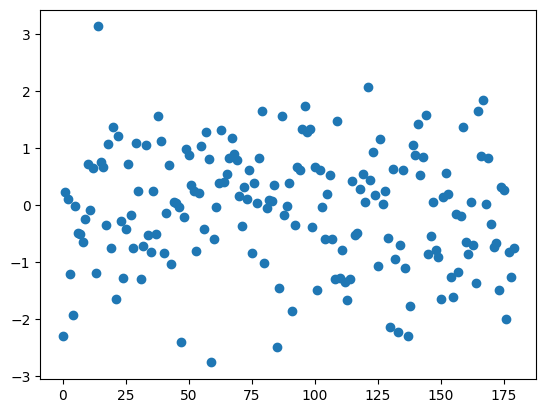

In [5]:
plt.scatter(np.arange(180),train[0][0])
plt.show()

In [6]:
layer1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # Downsamples sequence from 180 -> 90
        )

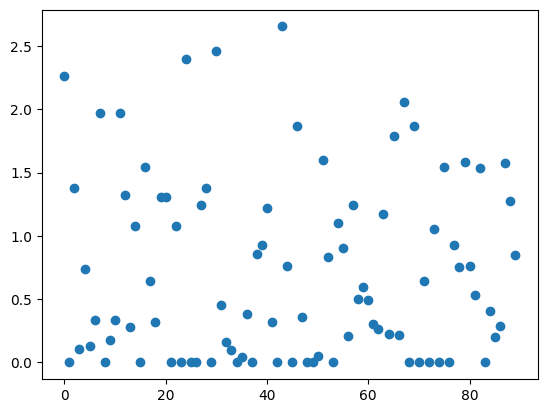

In [11]:
plt.scatter(np.arange(90),layer1(train).detach().numpy()[0][0])

In [12]:
layer2 = nn.Sequential(
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # Downsamples sequence from 90 -> 45
        )

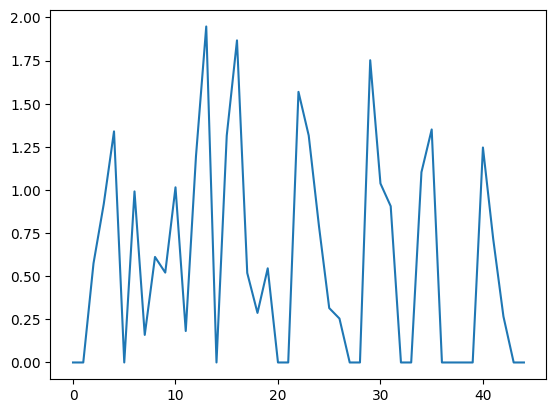

In [17]:
plt.plot(np.arange(45),layer2(layer1(train)).detach().numpy()[0][0])

In [18]:


class ECG1DCNN(nn.Module):
    def __init__(self):
        super(ECG1DCNN, self).__init__()
        
        # Block 1: Extracts low-level temporal features (spikes/edges)
        self.layer1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # Downsamples sequence from 180 -> 90
        )
        
        # Block 2: Combines low-level features into complex heartbeat shapes
        self.layer2 = nn.Sequential(
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # Downsamples sequence from 90 -> 45
        )
        
        # Global Pooling + Classifier
        self.global_pool = nn.AdaptiveAvgPool1d(1) # Flattens temporal dimension (45 -> 1)
        self.fc = nn.Linear(32, 2)                 # 32 features -> 2 classes
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)  # Reshapes (Batch, 32, 1) -> (Batch, 32)
        out = self.fc(x)
        return out

# Quick Sanity Check Test
if __name__ == "__main__":
    dummy_input = torch.randn(8, 1, 180)  # Batch of 8 synthetic heartbeats
    model = ECG1DCNN()
    output = model(dummy_input)
    print("Input Shape:", dummy_input.shape)
    print("Output Shape:", output.shape)  # Should be torch.Size([8, 2])

Input Shape: torch.Size([8, 1, 180])
Output Shape: torch.Size([8, 2])


In [19]:
output

tensor([[ 0.0986, -0.8020],
        [ 0.2248, -0.6550],
        [ 0.1877, -0.7350],
        [ 0.0576, -0.6661],
        [ 0.1612, -0.7595],
        [ 0.1400, -0.5905],
        [ 0.0909, -0.8343],
        [ 0.1920, -0.6052]], grad_fn=<AddmmBackward0>)